#  Application du KNN — Prédiction d'achat

> **Objectif :** Classer si un utilisateur va acheter un produit (`Purchased = 0 / 1`)  
> à partir de son âge, son salaire estimé et son genre.  
> On compare ici notre implémentation maison au `KNeighborsClassifier` de scikit-learn.

---
**Dataset :** `base3.csv`  
**Algorithme :** K-Nearest Neighbors (Classification)  
**Métrique :** Distance de Manhattan  
**Voisins (k) :** 7

## 1. Imports & Dépendances

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier

from KNN import KNN   # Notre implémentation

## 2. Chargement & Exploration des données

On commence par charger le dataset et inspecter sa structure avant tout prétraitement.

In [2]:
df = pd.read_csv('base3.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
print('Shape :', df.shape)
print('\nTypes :')
print(df.dtypes)
print('\nValeurs manquantes :')
print(df.isnull().sum())

Shape : (400, 5)

Types :
User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

Valeurs manquantes :
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


## 3. Prétraitement

Étapes :
- **Suppression** de `User ID` (identifiant sans valeur prédictive)
- **Encodage** de la variable catégorielle `Gender` (LabelEncoder)
- **Séparation** features / cible
- **Normalisation** des features (MinMaxScaler) — appliqué *après* le split pour éviter la fuite de données

In [4]:
# Suppression de l'identifiant
df.drop('User ID', axis=1, inplace=True)

# Encodage de Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Séparation features / cible
X = df.drop('Purchased', axis=1)
y = df['Purchased']

print("Features :", list(X.columns))
print("Distribution de la cible :")
print(y.value_counts())

Features : ['Gender', 'Age', 'EstimatedSalary']
Distribution de la cible :
Purchased
0    257
1    143
Name: count, dtype: int64


In [5]:
# Split train / test (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Normalisation (fit sur train uniquement)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")

Train : (320, 3)  |  Test : (80, 3)


## 4. KNN —  Implémentation From Scratch

Instanciation et entraînement du modèle avec `k=7` et la distance de Manhattan.

In [6]:
model_custom = KNN(k=7, distance_metric="manhattan", task="Classification")
model_custom.fit(X_train, y_train.values)

start = time.time()
predictions_custom = model_custom.predict(X_test)
t_custom = time.time() - start

print(f"Temps de prédiction (KNN From Scratch) : {t_custom:.4f} s")

Temps de prédiction (KNN From Scratch) : 0.0039 s


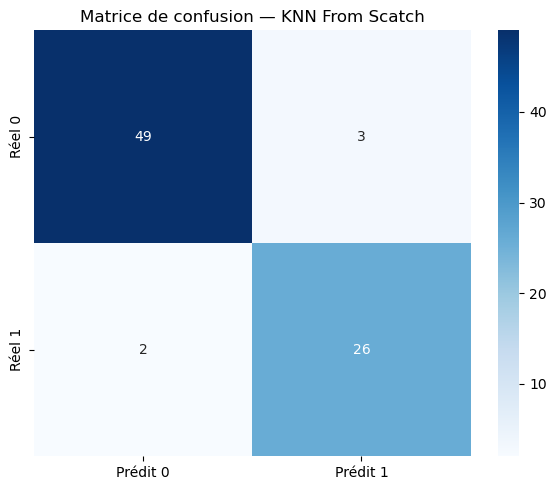

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        52
           1       0.90      0.93      0.91        28

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94        80



In [7]:
# Matrice de confusion
cm_custom = confusion_matrix(y_test, predictions_custom)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
plt.title("Matrice de confusion — KNN From Scatch")
plt.tight_layout()
plt.show()

print(classification_report(y_test, predictions_custom))

## 5. KNN — scikit-learn (référence)

On utilise `KNeighborsClassifier` avec les mêmes hyperparamètres pour comparer.

In [8]:
model_sklearn = KNeighborsClassifier(n_neighbors=7, metric='manhattan')
model_sklearn.fit(X_train, y_train)

start = time.time()
predictions_sklearn = model_sklearn.predict(X_test)
t_sklearn = time.time() - start

print(f"Temps de prédiction (Sklearn KNN) : {t_sklearn:.4f} s")

Temps de prédiction (Sklearn KNN) : 0.0065 s


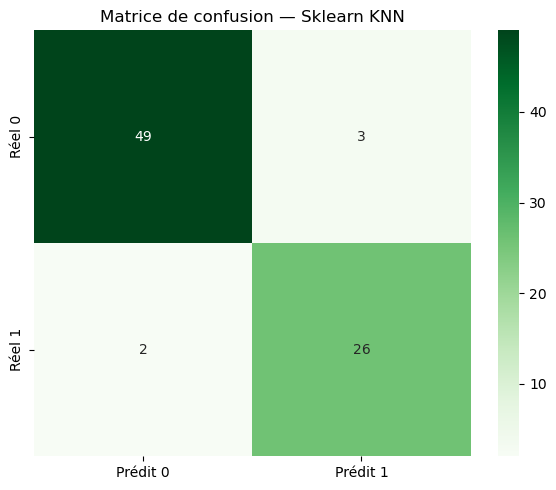

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        52
           1       0.90      0.93      0.91        28

    accuracy                           0.94        80
   macro avg       0.93      0.94      0.93        80
weighted avg       0.94      0.94      0.94        80



In [9]:
cm_sklearn = confusion_matrix(y_test, predictions_sklearn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
plt.title("Matrice de confusion — Sklearn KNN")
plt.tight_layout()
plt.show()

print(classification_report(y_test, predictions_sklearn))

## 6. Tableau de Benchmark

Comparaison directe des deux implémentations sur les métriques clés.

In [10]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def get_metrics(y_true, y_pred, t_pred):
    return {
        "Accuracy"  : round(accuracy_score(y_true, y_pred), 4),
        "Precision" : round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall"    : round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1-Score"  : round(f1_score(y_true, y_pred, zero_division=0), 4),
        "Temps préd. (s)": round(t_pred, 4),
    }

results = {
    "KNN From Scratch"      : get_metrics(y_test, predictions_custom, t_custom),
    "Sklearn KNN"  : get_metrics(y_test, predictions_sklearn, t_sklearn),
}

benchmark_df = pd.DataFrame(results).T
benchmark_df.index.name = "Modèle"
print("=" * 55)
print("           BENCHMARK — KNN (k=7, Manhattan)")
print("=" * 55)
print(benchmark_df.to_string())
print("=" * 55)
benchmark_df

           BENCHMARK — KNN (k=7, Manhattan)
                  Accuracy  Precision  Recall  F1-Score  Temps préd. (s)
Modèle                                                                  
KNN From Scratch    0.9375     0.8966  0.9286    0.9123           0.0039
Sklearn KNN         0.9375     0.8966  0.9286    0.9123           0.0065


,Accuracy,Precision,Recall,F1-Score,Temps préd. (s)
Modèle,,,,,
KNN From Scratch,0.9375,0.8966,0.9286,0.9123,0.0039
Sklearn KNN,0.9375,0.8966,0.9286,0.9123,0.0065


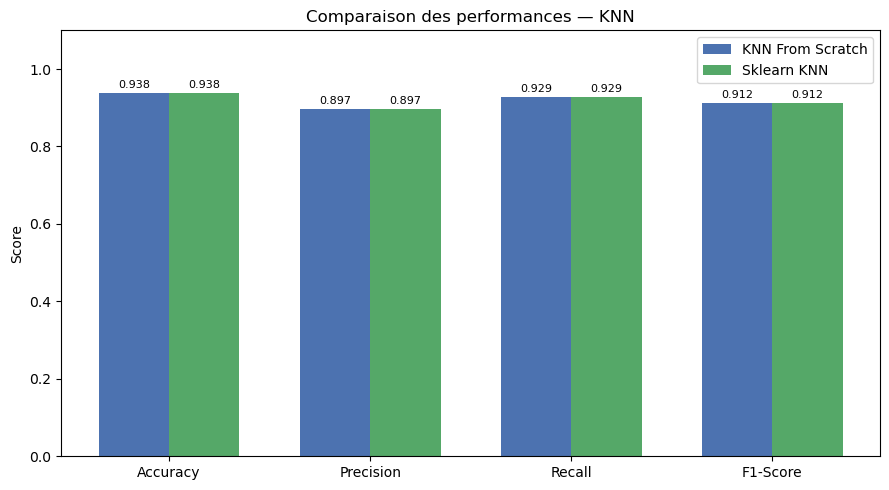

In [11]:
# Visualisation des métriques de performance
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, [benchmark_df.loc["KNN From Scratch", m] for m in metrics],
               width, label="KNN From Scratch", color="#4C72B0")
bars2 = ax.bar(x + width/2, [benchmark_df.loc["Sklearn KNN", m] for m in metrics],
               width, label="Sklearn KNN", color="#55A868")

ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Comparaison des performances — KNN")
ax.legend()
ax.bar_label(bars1, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(bars2, fmt="%.3f", padding=2, fontsize=8)
plt.tight_layout()
plt.show()

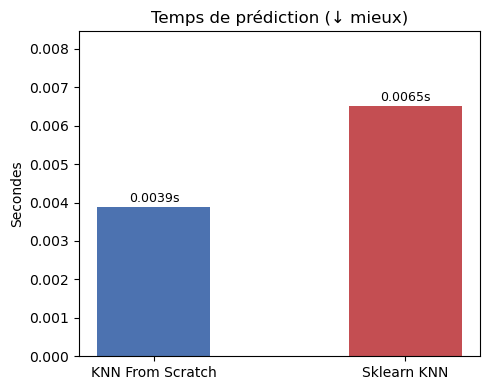

In [12]:
# Visualisation — Comparaison des temps de prédiction
fig, ax = plt.subplots(figsize=(5, 4))
modeles = ["KNN From Scratch", "Sklearn KNN"]
temps   = [t_custom, t_sklearn]
colors  = ["#4C72B0", "#C44E52"]

bars = ax.bar(modeles, temps, color=colors, width=0.45)
ax.set_title("Temps de prédiction (↓ mieux)")
ax.set_ylabel("Secondes")
ax.set_ylim(0, max(temps) * 1.3)
for bar, val in zip(bars, temps):
    ax.text(bar.get_x() + bar.get_width()/2, val + max(temps)*0.02,
            f"{val:.4f}s", ha='center', fontsize=9)
plt.tight_layout()
plt.show()